   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
age         0
sex         0
bmi         0
children    0
smoker      0
region     

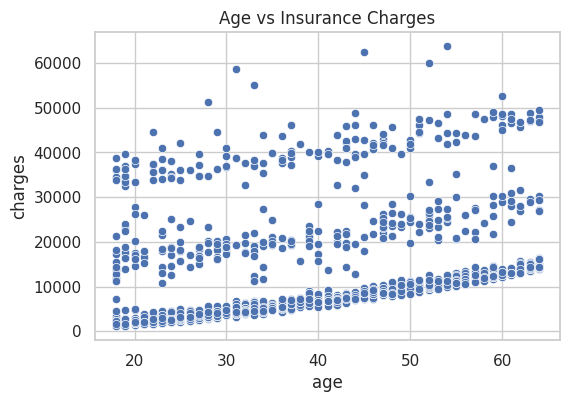

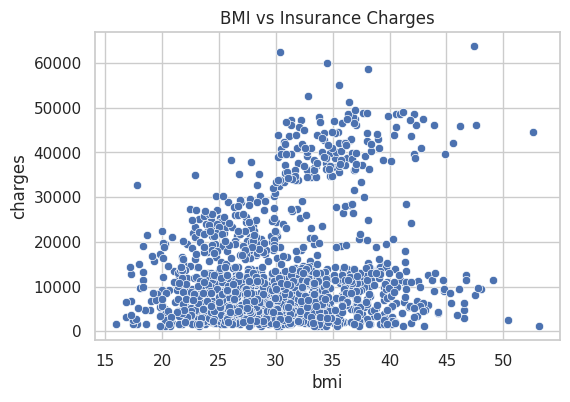

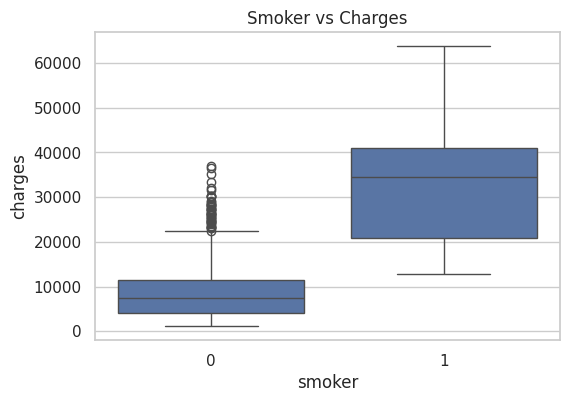

MAE: 4186.508898366433
RMSE: 5799.587091438356


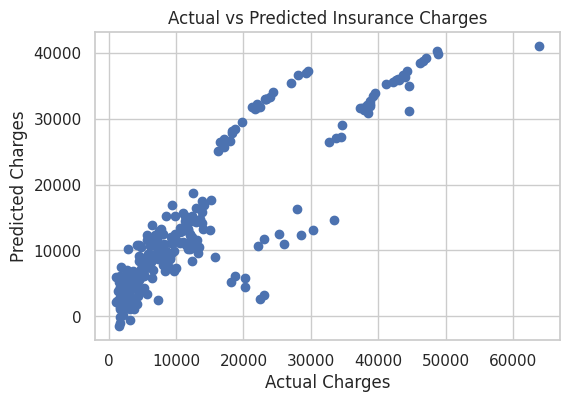


CONCLUSION:

A Linear Regression model was used to predict medical insurance costs.
Features like age, BMI, and smoking status strongly influence charges.

Model performance was evaluated using MAE and RMSE.
Smoking has the strongest impact on insurance cost.



In [1]:
# =========================
# TASK 4: INSURANCE COST PREDICTION (REGRESSION)
# =========================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")

# =========================
#  LOAD DATASET
# =========================
# Upload "insurance.csv" in Colab

df = pd.read_csv("insurance.csv")
print(df.head())

# =========================
# DATA EXPLORATION
# =========================
print(df.shape)
print(df.info())
print(df.isnull().sum())

# =========================
#  ENCODE CATEGORICAL DATA
# =========================
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

# =========================
# DATA VISUALIZATION
# =========================

# Age vs Charges
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"], y=df["charges"])
plt.title("Age vs Insurance Charges")
plt.show()

# BMI vs Charges
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["bmi"], y=df["charges"])
plt.title("BMI vs Insurance Charges")
plt.show()

# Smoker impact
plt.figure(figsize=(6,4))
sns.boxplot(x=df["smoker"], y=df["charges"])
plt.title("Smoker vs Charges")
plt.show()

# =========================
# SPLIT DATA
# =========================
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
#  MODEL TRAINING
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================
y_pred = model.predict(X_test)

# =========================
#  EVALUATION
# =========================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# =========================
# ACTUAL VS PREDICTED
# =========================
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

# =========================
#  CONCLUSION
# =========================
print("""
CONCLUSION:

A Linear Regression model was used to predict medical insurance costs.
Features like age, BMI, and smoking status strongly influence charges.

Model performance was evaluated using MAE and RMSE.
Smoking has the strongest impact on insurance cost.
""")